# TR1 South Cluster-Galaxy Clustering Analysis (PZWAV & AMICO)

Analysis of TR1 South cluster-galaxy clustering as a function of redshift and galaxy type for both PZWAV and AMICO cluster finders.

This notebook creates plots showing:
1. Single redshift bin comparison of galaxy types (separate plots for PZWAV & AMICO)
2. Redshift evolution for each galaxy type (separate plots for PZWAV & AMICO)
3. Galaxy type comparison across multiple redshift bins (separate plots for PZWAV & AMICO)
4. Direct comparison between PZWAV and AMICO cluster finders

## Configuration

Modify these settings to customize the plots.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import sys

# Add src to path (go up one directory from notebooks/)
sys.path.insert(0, '../src')
from plotting_utils import *

# ===== CONFIGURATION SETTINGS =====

# Pipeline base directory
BASE_DIR = Path('../')

# Output directories for PZWAV clusters
output_dirs_pzwav = {
    'all': BASE_DIR / 'outputs_tr1_pzwav_all',
    'early': BASE_DIR / 'outputs_tr1_pzwav_early',
    'late': BASE_DIR / 'outputs_tr1_pzwav_late'
}

# Output directories for AMICO clusters
output_dirs_amico = {
    'all': BASE_DIR / 'outputs_tr1_amico_all',
    'early': BASE_DIR / 'outputs_tr1_amico_early',
    'late': BASE_DIR / 'outputs_tr1_amico_late'
}

# Redshift bins (matching your config files)
redshift_bins = [
    (0.1, 0.4),
    (0.4, 0.7),
    (0.7, 1.0),
    (1.0, 1.3),
    (1.3, 1.6),
    (1.6, 1.9)
]

# Plot settings
FONT_SIZE_MINOR = 15
FONT_SIZE_MAJOR = 20

# Default redshift bin for single-bin plots
DEFAULT_Z_BIN = (0.4, 0.7)  # Change this to select different redshift bin

# Output directory for plots (in notebooks folder)
PLOT_OUTPUT_DIR = Path('plots_tr1_galaxy_type_analysis')
PLOT_OUTPUT_DIR.mkdir(exist_ok=True)

print(f"Configuration loaded successfully!")
print(f"Redshift bins: {len(redshift_bins)}")
print(f"Plots will be saved to: {PLOT_OUTPUT_DIR}")

# Check which directories have data for PZWAV
print("\n=== PZWAV Clusters ===")
for gal_type, dir_path in output_dirs_pzwav.items():
    if dir_path.exists():
        n_files = len(list(dir_path.glob('*.pkl')))
        print(f"  {gal_type}: {n_files} files")
    else:
        print(f"  {gal_type}: directory not found")

# Check which directories have data for AMICO
print("\n=== AMICO Clusters ===")
for gal_type, dir_path in output_dirs_amico.items():
    if dir_path.exists():
        n_files = len(list(dir_path.glob('*.pkl')))
        print(f"  {gal_type}: {n_files} files")
    else:
        print(f"  {gal_type}: directory not found")

## Setup Plot Style

In [2]:
# Set up plot style
setup_plot_style(font_size_minor=FONT_SIZE_MINOR, font_size_major=FONT_SIZE_MAJOR)
print("Plot style configured with serif font")

Plot style configured with serif font


## Plot 1: Single Redshift Bin - Galaxy Type Comparison (PZWAV & AMICO)

Shows clustering for all three galaxy types (all, early, late) in a single redshift bin for both cluster finders.

In [ ]:
def plot_type_comparison_single_z(z_bin, cluster_finder='pzwav', output_file=None):
    """
    Plot galaxy type comparison for a single redshift bin.
    
    Parameters
    ----------
    z_bin : tuple
        Redshift bin (z_min, z_max)
    cluster_finder : str
        'pzwav' or 'amico'
    output_file : str, optional
        Output filename
    """
    # Select output directories based on cluster finder
    output_dirs = output_dirs_pzwav if 'pzwav' in str(output_file).lower() else output_dirs_amico
    cluster_name = "PZWAV" if output_dirs == output_dirs_pzwav else "AMICO"
    
    fig, ax = plt.subplots(figsize=(10, 8))
    
    # Plot each galaxy type
    for gal_type in ['all', 'early', 'late']:
        # Find result file (no richness binning for TR1)
        files = find_result_files(
            output_dirs[gal_type],
            z_cluster_bin=z_bin,
            z_galaxy_bin=z_bin
        )
        
        if len(files) == 0:
            print(f"Warning: No results found for {gal_type} type")
            continue
        
        # Load results
        results = load_clustering_result(files[0])
        
        # Plot
        plot_correlation_function(
            ax, results['r'], results['xi'], results['sigma_xi'],
            label=get_galaxy_type_label(gal_type),
            color=get_galaxy_type_color(gal_type),
            marker='o', markersize=6
        )
    
    # Format axis
    format_clustering_axis(ax, xlim=(0.1, 60), ylim=(1e-2, 1e2))
    
    # Add title
    title = f"TR1 South {cluster_finder.upper()} - Cluster redshift: {get_redshift_bin_label(*z_bin)}"
    ax.set_title(title)
    
    plt.tight_layout()
    
    if output_file:
        plt.savefig(PLOT_OUTPUT_DIR / output_file, dpi=300, bbox_inches='tight')
        print(f"Saved: {output_file}")
    
    plt.show()

# Create plots for both cluster finders
for finder in ['pzwav', 'amico']:
    output_dirs = output_dirs_pzwav if finder == 'pzwav' else output_dirs_amico
    plot_type_comparison_single_z(
        DEFAULT_Z_BIN,
        output_dirs=output_dirs,
        cluster_finder=finder.upper(),
        output_file=f'plot1_type_comparison_single_z_{finder}.png'
    )

## Plot 2: Redshift Evolution - Three Panels (One per Galaxy Type)

Shows redshift evolution with 3 side-by-side panels (all, early, late types).

Saved: plot2_redshift_evolution.png


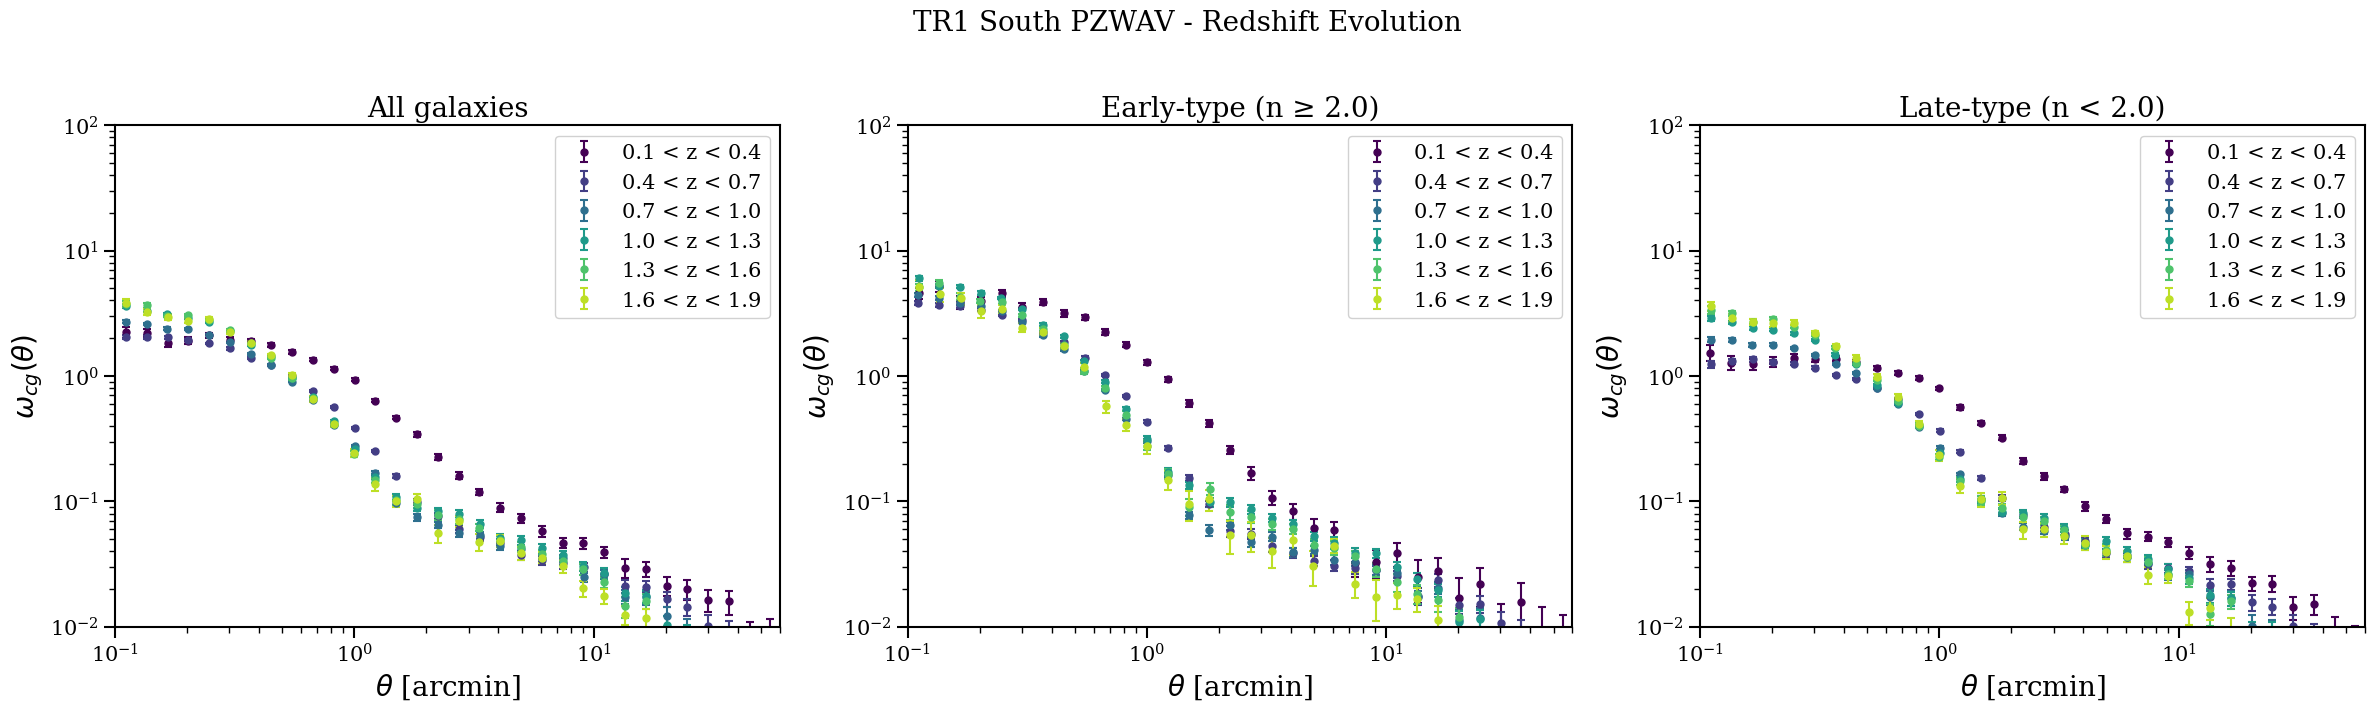

In [4]:
def plot_redshift_evolution(output_file=None):
    """
    Plot redshift evolution for all galaxy types in side-by-side panels.
    
    Parameters
    ----------
    output_file : str, optional
        Output filename
    """
    fig, axes = plt.subplots(1, 3, figsize=(24, 7))
    
    # Colors for redshift bins
    z_colors = plt.cm.viridis(np.linspace(0, 0.9, len(redshift_bins)))
    
    for j, gal_type in enumerate(['all', 'early', 'late']):
        ax = axes[j]
        
        # Plot each redshift bin
        for i, z_bin in enumerate(redshift_bins):
            # Find result file
            files = find_result_files(
                output_dirs[gal_type],
                z_cluster_bin=z_bin,
                z_galaxy_bin=z_bin
            )
            
            if len(files) == 0:
                continue
            
            # Load results
            results = load_clustering_result(files[0])
            
            # Plot
            plot_correlation_function(
                ax, results['r'], results['xi'], results['sigma_xi'],
                label=get_redshift_bin_label(*z_bin),
                color=z_colors[i],
                marker='o', markersize=5
            )
        
        # Format axis
        format_clustering_axis(ax, xlim=(0.1, 60), ylim=(1e-2, 1e2))
        ax.set_title(get_galaxy_type_label(gal_type))
    
    # Overall title
    fig.suptitle("TR1 South PZWAV - Redshift Evolution", fontsize=FONT_SIZE_MAJOR, y=1.02)
    
    plt.tight_layout()
    
    if output_file:
        plt.savefig(PLOT_OUTPUT_DIR / output_file, dpi=300, bbox_inches='tight')
        print(f"Saved: {output_file}")
    
    plt.show()

# Create redshift evolution plot
plot_redshift_evolution(output_file='plot2_redshift_evolution.png')

## Plot 3: Multiple Redshift Bins - Galaxy Type Comparison (1×3 Grid)

Shows 3 panels at different redshifts, each comparing the 3 galaxy types.

Saved: plot3_type_comparison_multiple_z.png


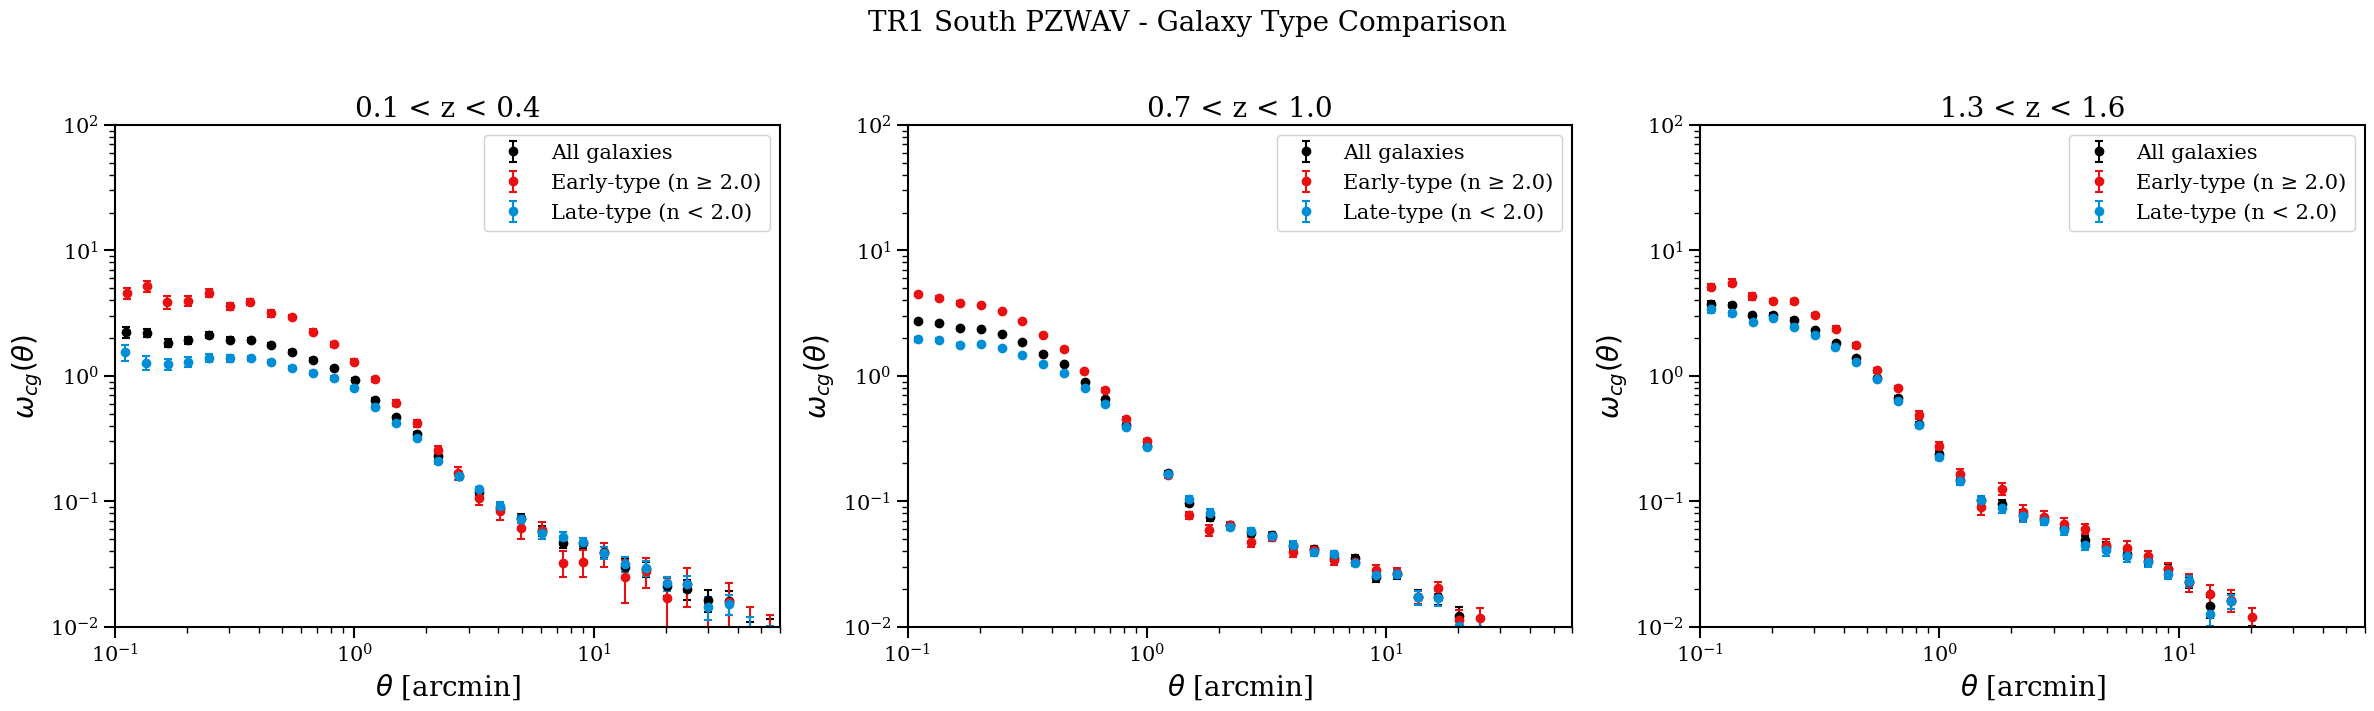

In [5]:
def plot_type_comparison_multiple_z(z_bins_to_plot=None, output_file=None):
    """
    Plot galaxy type comparison at multiple redshifts.
    
    Parameters
    ----------
    z_bins_to_plot : list of tuples, optional
        List of 3 redshift bins to plot. Default: [(0.1,0.4), (0.7,1.0), (1.3,1.6)]
    output_file : str, optional
        Output filename
    """
    if z_bins_to_plot is None:
        z_bins_to_plot = [(0.1, 0.4), (0.7, 1.0), (1.3, 1.6)]
    
    fig, axes = plt.subplots(1, 3, figsize=(24, 7))
    
    for i, z_bin in enumerate(z_bins_to_plot):
        ax = axes[i]
        
        # Plot each galaxy type
        for gal_type in ['all', 'early', 'late']:
            # Find result file
            files = find_result_files(
                output_dirs[gal_type],
                z_cluster_bin=z_bin,
                z_galaxy_bin=z_bin
            )
            
            if len(files) == 0:
                continue
            
            # Load results
            results = load_clustering_result(files[0])
            
            # Plot
            plot_correlation_function(
                ax, results['r'], results['xi'], results['sigma_xi'],
                label=get_galaxy_type_label(gal_type),
                color=get_galaxy_type_color(gal_type),
                marker='o', markersize=6
            )
        
        # Format axis
        format_clustering_axis(ax, xlim=(0.1, 60), ylim=(1e-2, 1e2))
        
        # Add subtitle
        ax.set_title(get_redshift_bin_label(*z_bin))
    
    # Overall title
    fig.suptitle("TR1 South PZWAV - Galaxy Type Comparison", 
                 fontsize=FONT_SIZE_MAJOR, y=1.02)
    
    plt.tight_layout()
    
    if output_file:
        plt.savefig(PLOT_OUTPUT_DIR / output_file, dpi=300, bbox_inches='tight')
        print(f"Saved: {output_file}")
    
    plt.show()

# Create plot comparing low-z, mid-z, high-z
plot_type_comparison_multiple_z(
    z_bins_to_plot=[(0.1, 0.4), (0.7, 1.0), (1.3, 1.6)],
    output_file='plot3_type_comparison_multiple_z.png'
)

## Plot 4: Galaxy Redshift Slices at Different Cluster Redshifts

Shows θ × w_cg(θ) for galaxies at different redshift slices, with panels for different cluster redshift bins.

Saved: plot4_galaxy_slices_all.png


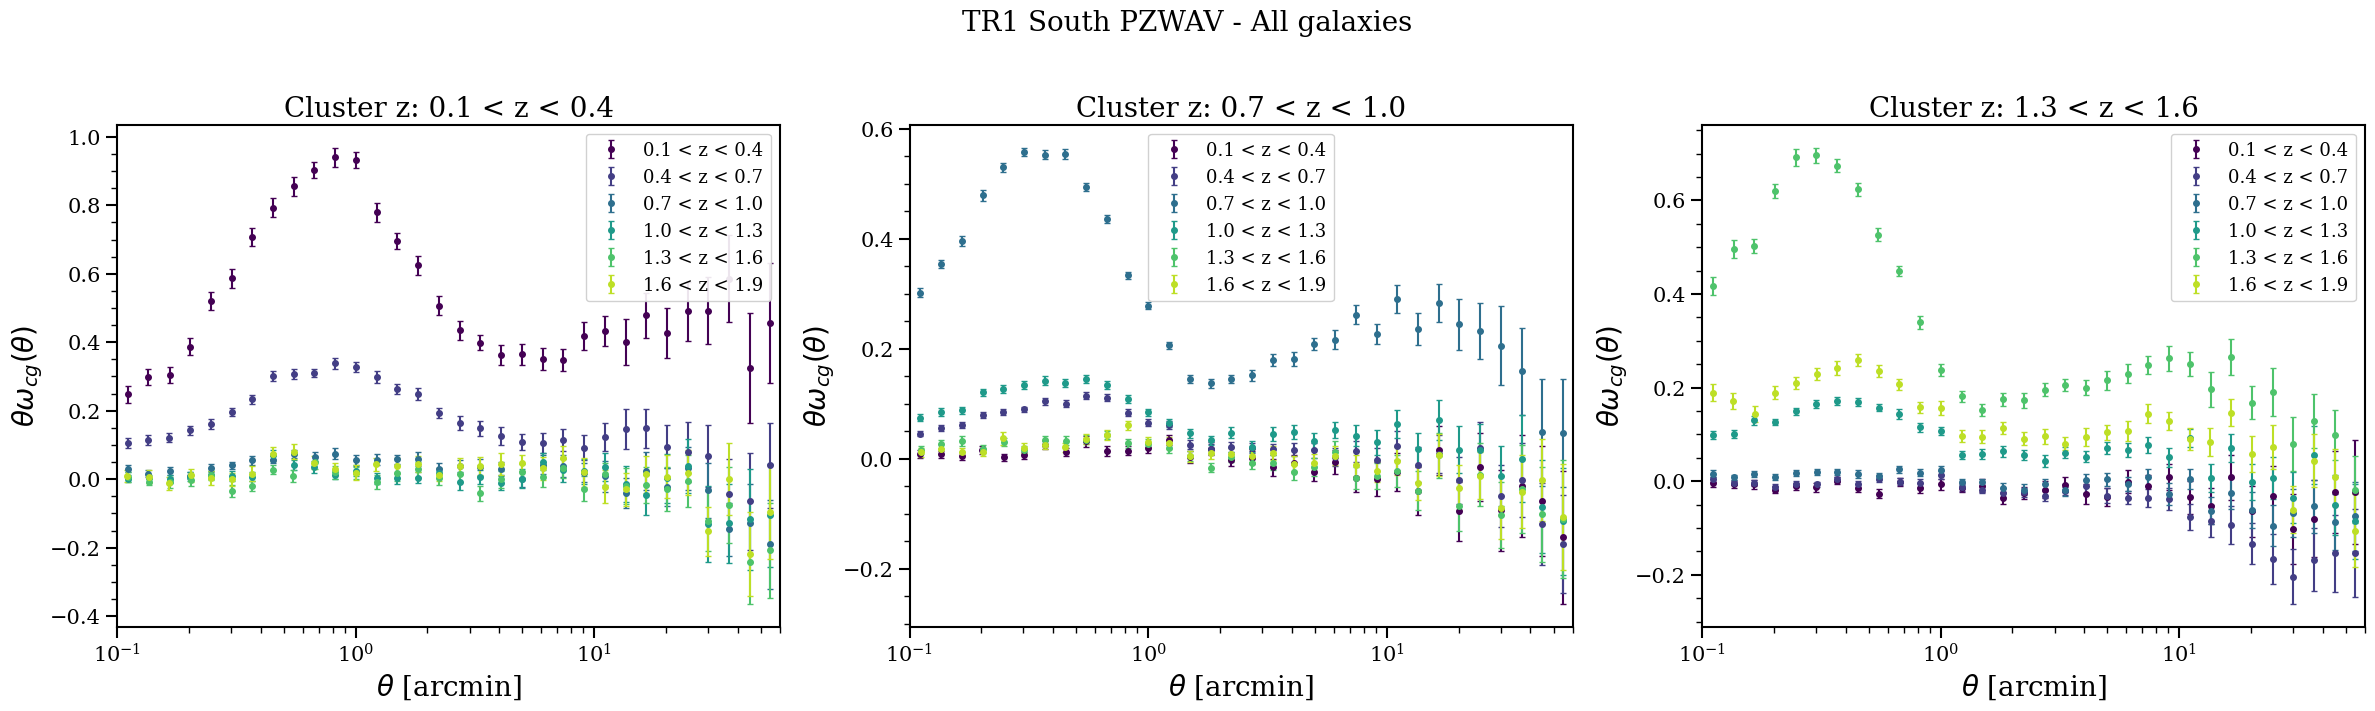

Saved: plot4_galaxy_slices_early.png


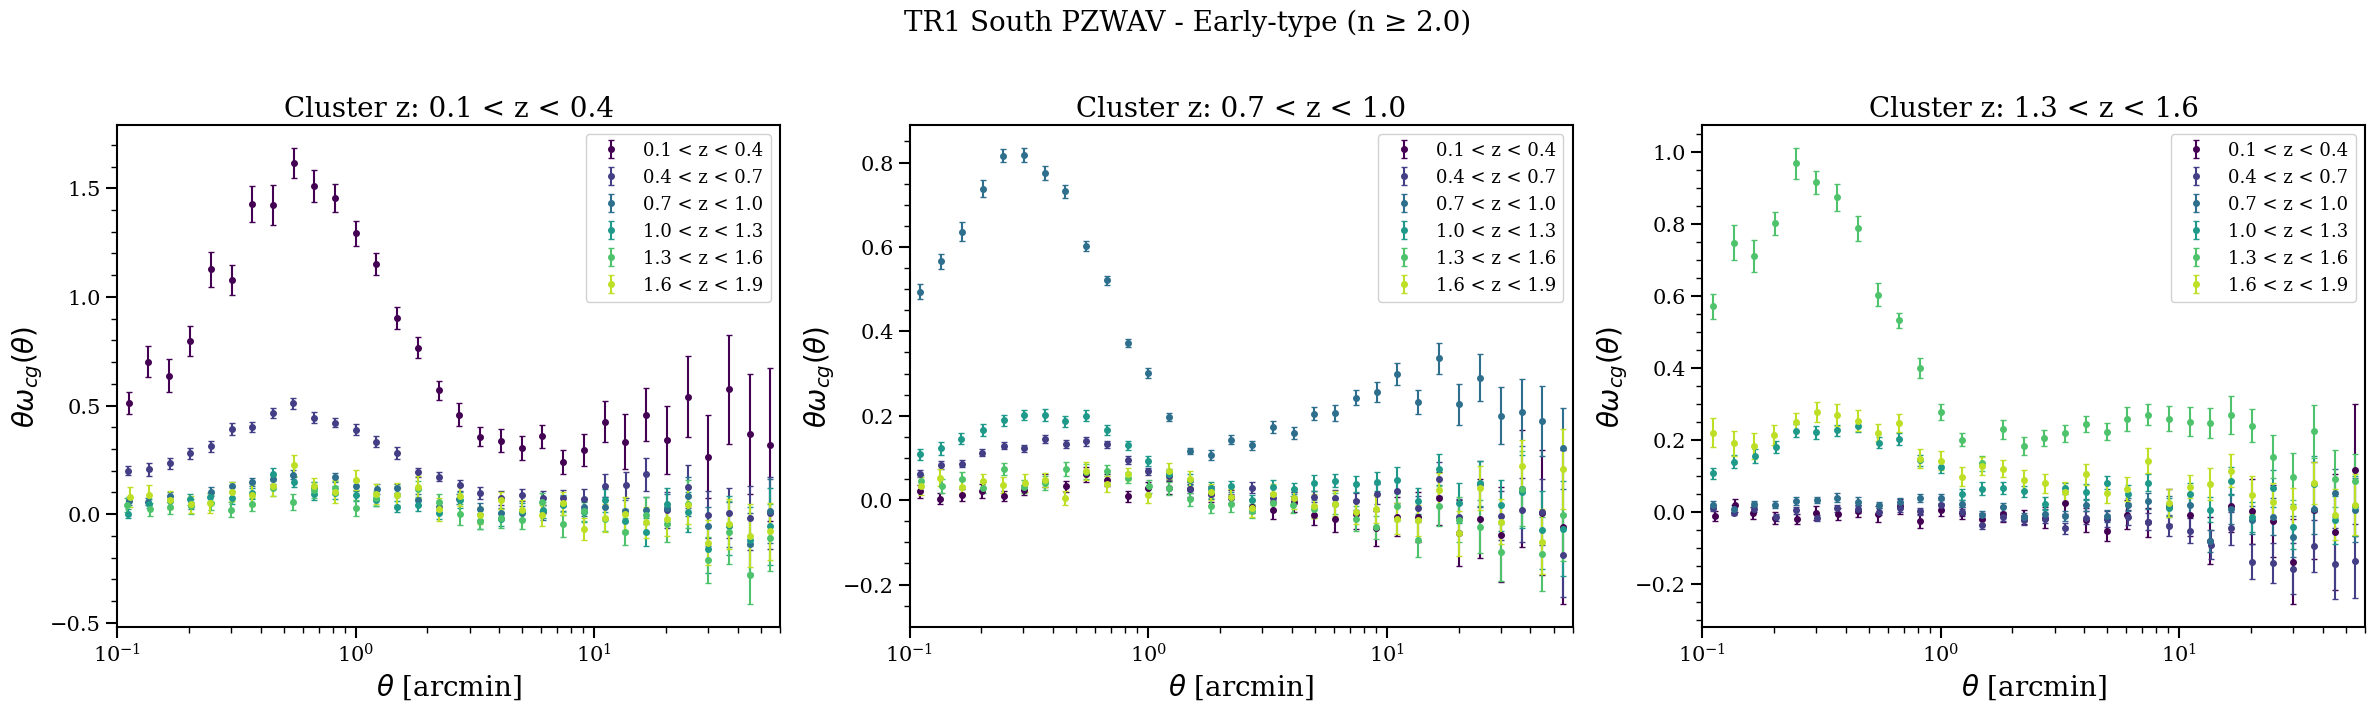

Saved: plot4_galaxy_slices_late.png


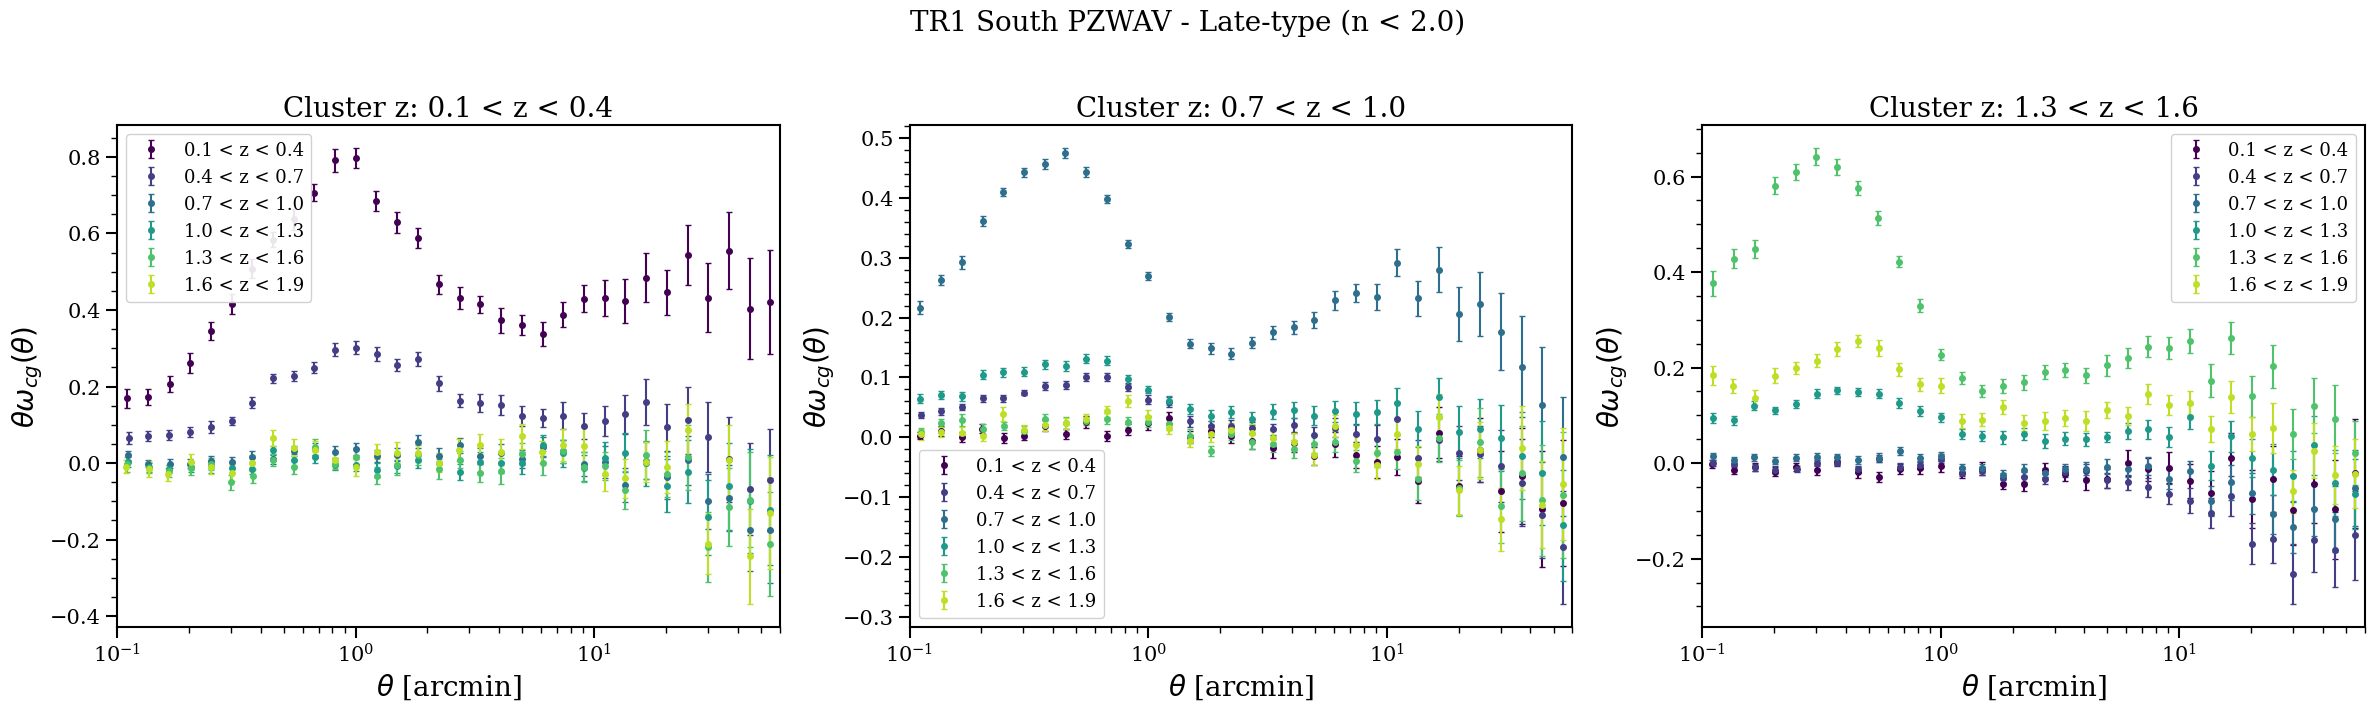


Note: This plot shows θ × w_cg(θ) for galaxies at different redshift slices.
Each panel shows a different cluster redshift bin.


In [6]:
def plot_galaxy_slices_multiple_cluster_z(cluster_z_bins=None, gal_type='all', output_file=None):
    """
    Plot galaxy clustering at different galaxy redshift slices for multiple cluster redshift bins.
    Shows θ × w_cg(θ) in a 1×3 grid, one panel per cluster redshift bin.
    
    Parameters
    ----------
    cluster_z_bins : list of tuples, optional
        List of cluster redshift bins. Default: [(0.1,0.4), (0.7,1.0), (1.3,1.6)]
    gal_type : str
        Galaxy type: 'all', 'early', or 'late'
    output_file : str, optional
        Output filename
    """
    if cluster_z_bins is None:
        cluster_z_bins = [(0.1, 0.4), (0.7, 1.0), (1.3, 1.6)]
    
    fig, axes = plt.subplots(1, 3, figsize=(24, 7))
    
    # Colors for different galaxy redshift bins
    z_colors = plt.cm.viridis(np.linspace(0, 0.9, len(redshift_bins)))
    
    for j, cluster_z_bin in enumerate(cluster_z_bins):
        ax = axes[j]
        
        # Plot each galaxy redshift slice
        for i, galaxy_z_bin in enumerate(redshift_bins):
            # Find result file for this cluster z bin and galaxy z bin
            files = find_result_files(
                output_dirs[gal_type],
                z_cluster_bin=cluster_z_bin,
                z_galaxy_bin=galaxy_z_bin
            )
            
            if len(files) == 0:
                continue
            
            # Load results
            results = load_clustering_result(files[0])
            
            # Plot θ × w_cg(θ) instead of just w_cg(θ)
            r = results['r']
            xi = results['xi']
            sigma_xi = results['sigma_xi']
            
            # Multiply by θ to emphasize different scales
            theta_times_wcg = r * xi
            theta_times_sigma = r * sigma_xi
            
            # Filter valid points
            valid = (r > 0) & np.isfinite(theta_times_wcg) & np.isfinite(theta_times_sigma) & (theta_times_sigma > 0)
            
            ax.errorbar(
                r[valid], 
                theta_times_wcg[valid], 
                yerr=theta_times_sigma[valid],
                label=f"{get_redshift_bin_label(*galaxy_z_bin)}",
                color=z_colors[i],
                marker='o',
                markersize=4,
                linestyle='none',
                capsize=2,
                capthick=1.0
            )
        
        # Format axis
        ax.set_xlabel(r'$\theta$ [arcmin]')
        ax.set_ylabel(r'$\theta \omega_{cg}(\theta)$')
        ax.set_xscale('log')
        ax.set_xlim(0.1, 60)
        ax.legend(frameon=True, framealpha=0.9, fontsize=FONT_SIZE_MINOR-2)
        ax.minorticks_on()
        
        # Subtitle for each panel
        ax.set_title(f"Cluster z: {get_redshift_bin_label(*cluster_z_bin)}")
    
    # Overall title
    title = f"TR1 South PZWAV - {get_galaxy_type_label(gal_type)}"
    fig.suptitle(title, fontsize=FONT_SIZE_MAJOR, y=1.02)
    
    plt.tight_layout()
    
    if output_file:
        plt.savefig(PLOT_OUTPUT_DIR / output_file, dpi=300, bbox_inches='tight')
        print(f"Saved: {output_file}")
    
    plt.show()

# Create plots for each galaxy type
default_cluster_z_bins = [(0.1, 0.4), (0.7, 1.0), (1.3, 1.6)]

for gal_type in ['all', 'early', 'late']:
    plot_galaxy_slices_multiple_cluster_z(
        cluster_z_bins=default_cluster_z_bins,
        gal_type=gal_type,
        output_file=f'plot4_galaxy_slices_{gal_type}.png'
    )

print("\nNote: This plot shows θ × w_cg(θ) for galaxies at different redshift slices.")
print("Each panel shows a different cluster redshift bin.")

## Summary

In [7]:
print("\n" + "="*70)
print("PLOTTING COMPLETE")
print("="*70)
print(f"\nAll plots saved to: {PLOT_OUTPUT_DIR}")
print(f"\nGenerated plots:")
for plot_file in sorted(PLOT_OUTPUT_DIR.glob('*.png')):
    print(f"  - {plot_file.name}")


PLOTTING COMPLETE

All plots saved to: plots_tr1_galaxy_type_analysis

Generated plots:
  - plot1_type_comparison_single_z.png
  - plot2_redshift_evolution.png
  - plot3_type_comparison_multiple_z.png
  - plot4_galaxy_slices_all.png
  - plot4_galaxy_slices_early.png
  - plot4_galaxy_slices_late.png
